# Load and Visualize ECG Data from EDF File

First, we'll import the `mne` library, which is a Python package for analyzing MEG, EEG, and other electrophysiological data. Then, we'll load the specified EDF file and display some basic information about it. Finally, we'll plot the ECG channels.

In [1]:
!pip install mne -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 33.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [24]:
# Install MNE if not already installed (uncomment the line below if needed)
# !pip install mne -q

import mne
import matplotlib.pyplot as plt
import os

# Use the direct raw link provided by the user
data_link_source = 'https://raw.githubusercontent.com/D2718281828nis/BioMedAI-Wavelet-P_R_T_peaks-detection/refs/heads/main/dataset_4_test/01_ГУСА.edf'

# Define the local path where the EDF file will be stored
# We will use the last part of the URL as the local filename.
# If it doesn't already have an .edf extension, we'll add one for MNE compatibility.
local_file_name_from_url = data_link_source.split('/')[-1]
if not local_file_name_from_url.lower().endswith('.edf'):
    local_file_name = local_file_name_from_url + '.edf'
else:
    local_file_name = local_file_name_from_url

edf_file_path = os.path.join('/tmp', local_file_name)

# Use !wget to download the file
print(f"Attempting to download {data_link_source} to {edf_file_path} using wget...")

# Delete existing file to ensure a fresh download, especially if previous attempts were corrupted
if os.path.exists(edf_file_path):
    print(f"Deleting existing file at {edf_file_path} to ensure fresh download.")
    os.remove(edf_file_path)

# Execute wget command silently (-q) and force output to specific filename (-O)
!wget -q -O {edf_file_path} {data_link_source}

# Verify if download was successful (check file existence and size)
MIN_EDF_SIZE_BYTES = 256 # A typical EDF header is 256 bytes

if os.path.exists(edf_file_path):
    file_size = os.path.getsize(edf_file_path)
    if file_size < MIN_EDF_SIZE_BYTES:
        print(f"Error: Downloaded file is too small ({file_size} bytes). This likely indicates the URL is incorrect (e.g., a 404 Not Found error) or the file is corrupted.")
        edf_file_path = None # Mark as invalid
    else:
        print(f"Download successful. File size: {file_size} bytes.")
else:
    print("Error: Download failed or file was not created by wget. Check the URL and network connection.")
    edf_file_path = None


# Initialize raw to None to prevent NameError if loading fails
raw = None

if edf_file_path:
    try:
        # Load the EDF file
        print(f"Loading EDF file from {edf_file_path} with MNE...")
        raw = mne.io.read_raw_edf(edf_file_path, preload=True)

        # Display basic information about the loaded data
        display(raw.info)

        # Filter out 'bad' channels if any
        initial_channel_count = len(raw.ch_names)
        raw.info['bads'] = [ch for ch in raw.ch_names if 'bad' in ch.lower()]
        if raw.info['bads']:
            print(f"Excluding bad channels: {raw.info['bads']}")
            raw.pick_channels([ch for ch in raw.ch_names if ch not in raw.info['bads']])

        print(f"Number of channels after filtering: {len(raw.ch_names)} (from {initial_channel_count})")

    except Exception as e:
        print(f"Error loading EDF file with MNE: {e}")
        print("The file might be genuinely corrupted or malformed, or MNE has trouble parsing it.")
        raw = None # Ensure raw is None if loading fails

# If raw is still None, indicate that processing cannot proceed
if raw is None:
    print("Cannot proceed with EDF data processing as 'raw' object is not defined.")

Attempting to download https://raw.githubusercontent.com/D2718281828nis/BioMedAI-Wavelet-P_R_T_peaks-detection/refs/heads/main/dataset_4_test/01_ГУСА.edf to /tmp/01_ГУСА.edf using wget...
Download successful. File size: 3997024 bytes.
Loading EDF file from /tmp/01_ГУСА.edf with MNE...
Extracting EDF parameters from /tmp/01_ГУСА.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 665999  =      0.000 ...  3329.995 secs...


<Info | 8 non-empty values
 bads: []
 ch_names: ECG V2-Ref, ECG V5-Ref, ECG avF-Ref
 chs: 3 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 100.0 Hz
 meas_date: 2017-11-14 11:30:20 UTC
 nchan: 3
 projs: []
 sfreq: 200.0 Hz
 subject_info: <subject_info | his_id: >
>

Number of channels after filtering: 3 (from 3)


Found ECG channels: ['ECG V2-Ref', 'ECG V5-Ref', 'ECG avF-Ref']
Using matplotlib as 2D backend.


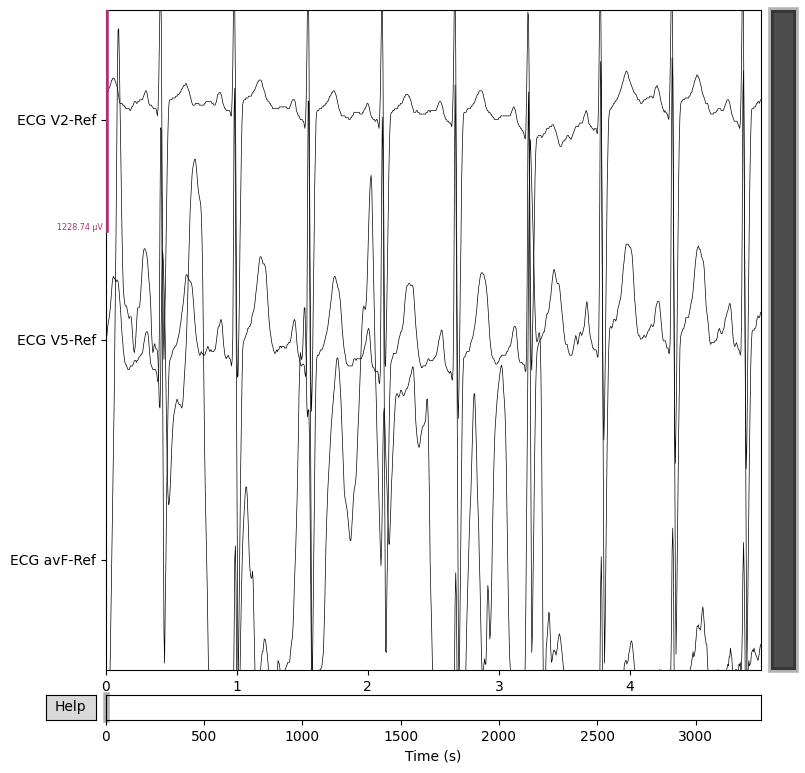

<Figure size 640x480 with 0 Axes>

In [25]:
# Find ECG channels (assuming channels containing 'ECG' in their names)
ecg_channels = [ch for ch in raw.ch_names if 'ECG' in ch.upper()]

if ecg_channels:
    print(f"Found ECG channels: {ecg_channels}")
    # Plot ECG channels
    # We'll plot a segment of the data to make it manageable
    # Adjust duration and n_channels as needed
    raw.plot(duration=5, start=0, n_channels=len(ecg_channels), scalings='auto', picks=ecg_channels, show_scrollbars=True)
    plt.tight_layout()
    plt.show()
else:
    print("No ECG channels found in the file. Plotting all channels for a quick overview.")
    # If no ECG channels are explicitly named, plot all channels
    raw.plot(duration=5, start=0, n_channels=5, scalings='auto', show_scrollbars=True)
    plt.tight_layout()
    plt.show()

#0. data that we work with

In [39]:
# Get the 'ECG V2-Ref' channel data
# Assuming raw, sfreq, and ecg_channels are available from previous cells

# Find the index of 'ECG V2-Ref' in raw.ch_names
try:
    ecg_v2_ref_idx = raw.ch_names.index('ECG V2-Ref')
except ValueError:
    print("Error: 'ECG V2-Ref' channel not found in the raw data.")
    raise

ec_v2_ref_data = raw.get_data(picks='ECG V2-Ref').flatten() * 1e6 # Convert to microvolts
sfreq = raw.info['sfreq']

# Define the time window
start_time_s = 0
duration_s = 5
end_time_s = start_time_s + duration_s

# Convert time window to sample indices
start_sample = int(start_time_s * sfreq)
end_sample = int(end_time_s * sfreq)

# Ensure the window is within the bounds of the data
start_sample = max(0, start_sample)
end_sample = min(len(ec_v2_ref_data), end_sample)

# Extract the ECG data for the specified window
windowed_ecg_data = ec_v2_ref_data[start_sample:end_sample]
time_axis_windowed = np.arange(start_sample, end_sample) / sfreq

print(f"Processing 'ECG V2-Ref' channel from {start_time_s}s to {end_time_s}s.")

Processing 'ECG V2-Ref' channel from 0s to 5s.


# 1. Baseline - Neurophysiological Signal Processing (NeuroKit2)

Use the `neurokit2` library to detect R-peaks on the 'ECG V2-Ref' channel and visualize the results.

In [26]:
# Install NeuroKit2
!pip install neurokit2 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 12.3 MB/s eta 0:00:00


In [40]:
import neurokit2 as nk
import matplotlib.pyplot as plt
import numpy as np



Detected 9 R-peaks using NeuroKit2.


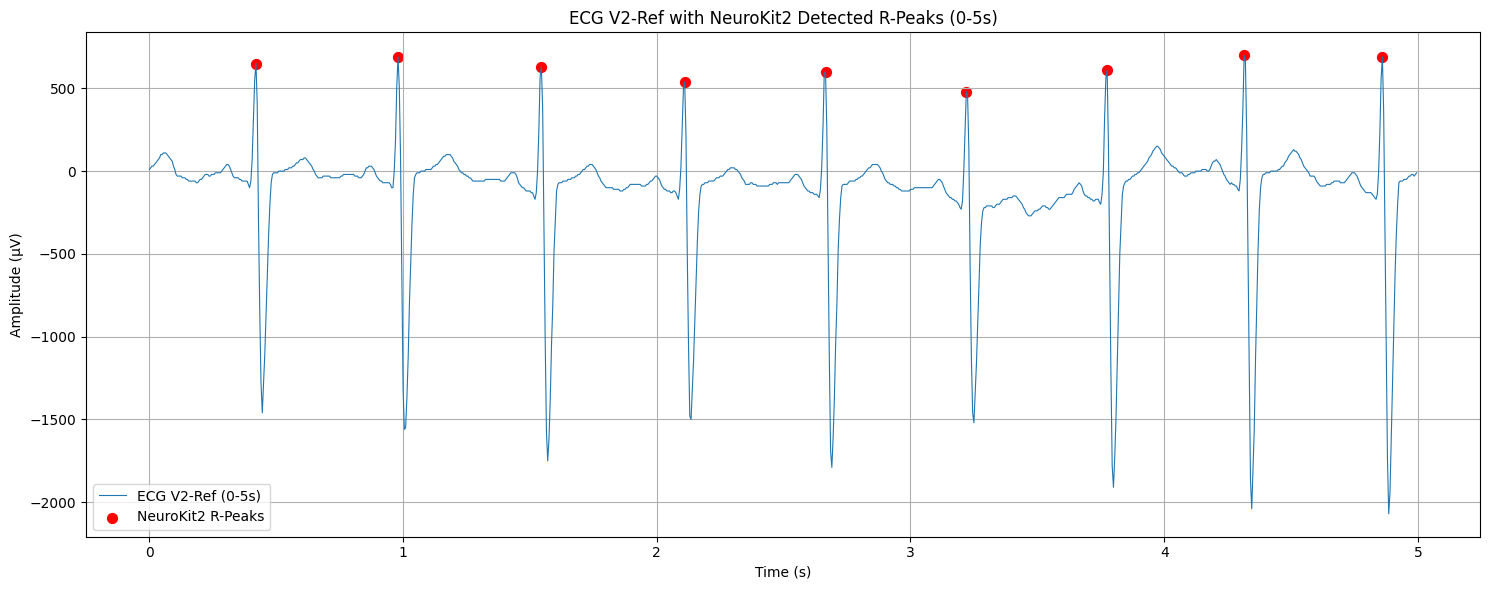

In [41]:
# Process the ECG signal to find R-peaks using NeuroKit2
# NeuroKit expects samples, so we pass the windowed data and its sampling frequency
peaks, info = nk.ecg_peaks(windowed_ecg_data, sampling_rate=sfreq, method='neurokit')

# Get R-peak locations in samples relative to the start of the windowed_ecg_data
r_peaks_local_indices = info['ECG_R_Peaks']

# Convert local R-peak indices to global time (seconds) for plotting
r_peaks_global_time = (r_peaks_local_indices + start_sample) / sfreq

print(f"Detected {len(r_peaks_local_indices)} R-peaks using NeuroKit2.")

# Plot the windowed ECG signal and mark the R-peaks
plt.figure(figsize=(15, 6))
plt.plot(time_axis_windowed, windowed_ecg_data, label='ECG V2-Ref (0-5s)', linewidth=0.8)
plt.scatter(r_peaks_global_time, windowed_ecg_data[r_peaks_local_indices], color='red', s=50, marker='o', label='NeuroKit2 R-Peaks')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.title('ECG V2-Ref with NeuroKit2 Detected R-Peaks (0-5s)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
windowed_ecg_data[r_peaks_local_indices]

array([650., 690., 630., 540., 600., 480., 610., 700., 690.])

In [43]:
r_peaks_global_time

array([0.42 , 0.98 , 1.545, 2.11 , 2.665, 3.22 , 3.775, 4.315, 4.86 ])

#2. Wavelet Transform and Modified Shannon Energy Envelope - 2017 year method
https://pmc.ncbi.nlm.nih.gov/articles/PMC5516746/pdf/JHE2017-4901017.pdf$0


Starting WTSEE R-peak detection for: ECG V2-Ref (0-5s window)
Processing preloaded signal: ECG V2-Ref (0-5s window) at 200.0 Hz
Original signal length for ECG V2-Ref (0-5s window): 1000
Denoised signal (EF) length: 1000
Initial peaks found in PSE (downsampled space) for ECG V2-Ref (0-5s window): 17
Refined peaks (in EF signal space) for ECG V2-Ref (0-5s window): 17
Final validated peaks for ECG V2-Ref (0-5s window): 11
Detected 11 R-peaks for ECG V2-Ref (0-5s window).


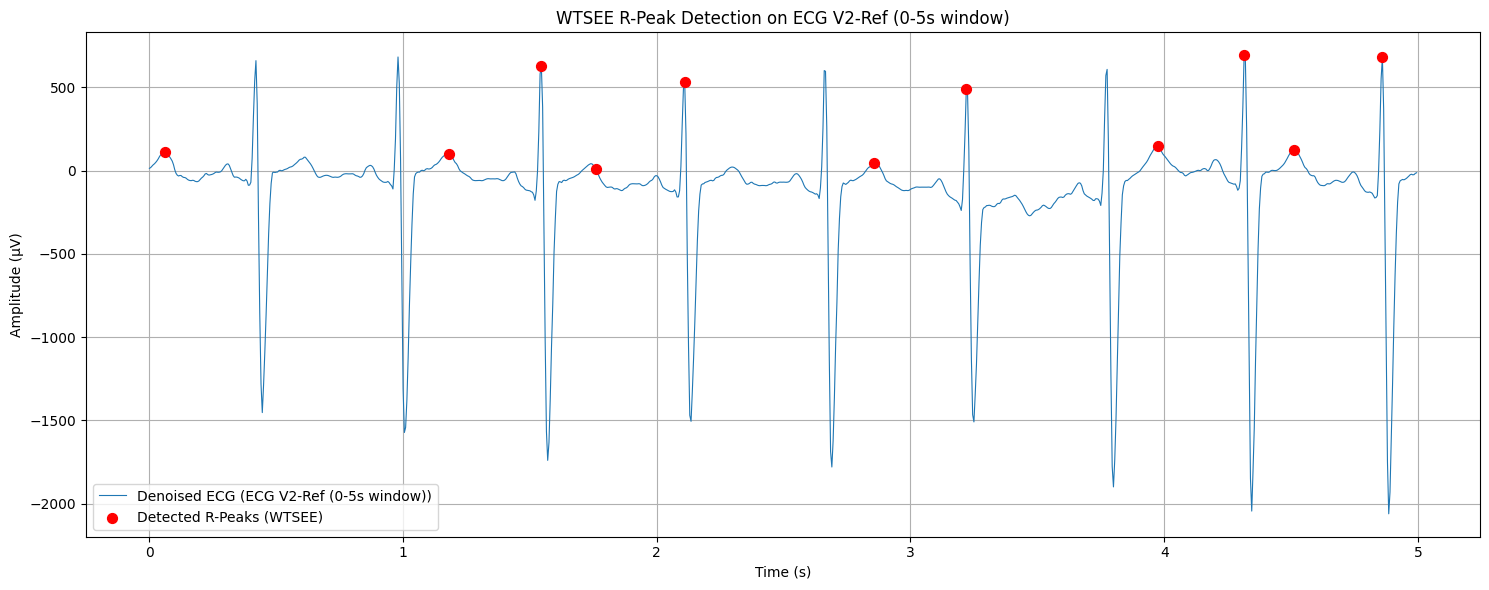

In [46]:
# --- Install Required Libraries ---
# Run this cell only once per session if libraries are not already installed
!pip install pyEDFlib PyWavelets -q

# --- Import Libraries ---
import numpy as np
import pyedflib # Library to read EDF files
import pywt     # Library for wavelet transforms
from scipy import signal # For moving average filtering
import matplotlib.pyplot as plt # For plotting

# --- Helper Functions ---

def calculate_threshold(coeffs):
    """Calculates universal threshold for soft thresholding."""
    sigma = np.median(np.abs(coeffs)) / 0.6745
    N = len(coeffs)
    return sigma * np.sqrt(2 * np.log(N))

def apply_soft_threshold(coeffs, threshold):
    """Applies soft thresholding."""
    return np.sign(coeffs) * np.maximum(np.abs(coeffs) - threshold, 0)

def find_peaks_in_pse(pse_signal, height=None, distance=1):
    """
    Finds peaks in the Peak Energy Envelope (PSE) signal.
    Uses scipy.signal.find_peaks. No amplitude threshold needed based on the paper.
    """
    peaks, _ = signal.find_peaks(pse_signal, height=height, distance=distance)
    return peaks

def update_r_peaks(r_candidates, fs, alpha=0.5, beta=1.5, gamma=0.5):
    """
    Validates and updates R peaks based on R-R intervals.
    """
    if len(r_candidates) < 2:
        return r_candidates

    # Calculate initial R-R intervals
    rr_intervals = np.diff(r_candidates)

    # Estimate average R-R interval (using median might be more robust)
    avg_rr_samples = int(np.median(rr_intervals))

    # Define thresholds based on average interval
    theta_delta_1 = int(alpha * avg_rr_samples)
    theta_delta_2 = int(beta * avg_rr_samples)
    gamma_search = int(gamma * avg_rr_samples)

    simple_final_peaks = []
    for i in range(len(r_candidates)):
        current_peak = r_candidates[i]
        prev_interval = rr_intervals[i-1] if i > 0 else float('inf')
        curr_interval = rr_intervals[i] if i < len(rr_intervals) else float('inf')

        if theta_delta_1 <= prev_interval <= theta_delta_2 and theta_delta_1 <= curr_interval <= theta_delta_2:
             simple_final_peaks.append(current_peak)
        elif i == 0 and curr_interval <= theta_delta_2: # First peak case
             simple_final_peaks.append(current_peak)
        elif i == len(r_candidates)-1 and prev_interval <= theta_delta_2: # Last peak case
             simple_final_peaks.append(current_peak)
        # Note: This simple rule might not perfectly match the paper's complex logic,
        # especially for missed peak insertion, but covers basic validation.

    # Return the simpler version for now. The complex logic needs original signal access for missed peaks.
    return simple_final_peaks

# --- Main R-Peak Detection Function (WTSEE Algorithm) ---
def detect_r_peaks_wf(edf_file_path=None, ecg_channel_index=0, fs_expected=None, preloaded_signal=None, preloaded_fs=None, channel_name_for_logging=None):
    """
    Detects R peaks in an ECG signal using the WTSEE algorithm, either from an EDF file
    or from a preloaded signal.

    Args:
        edf_file_path (str, optional): Path to the EDF file. Required if preloaded_signal is None.
        ecg_channel_index (int): Index of the ECG channel in the file (default 0). Used if reading from EDF.
        fs_expected (float, optional): Expected sampling frequency. Used if not available in file header or if preloaded.
        preloaded_signal (np.ndarray, optional): Preloaded ECG signal array. If provided, edf_file_path is ignored.
        preloaded_fs (float, optional): Sampling frequency of the preloaded signal. Required if preloaded_signal is provided.
        channel_name_for_logging (str, optional): Name of the channel being processed, for logging.

    Returns:
        tuple: (timestamps_of_detected_peaks, denoised_ecg_signal, sampling_frequency)
               Returns (None, None, None) if an error occurs.
    """
    ei_signal = None
    fs = None
    current_channel_name = channel_name_for_logging if channel_name_for_logging else "Unknown Channel"

    try:
        if preloaded_signal is not None and preloaded_fs is not None:
            ei_signal = preloaded_signal.astype(float)
            fs = preloaded_fs
            print(f"Processing preloaded signal: {current_channel_name} at {fs} Hz")
        elif edf_file_path:
            # 1. Read EDF file
            f = pyedflib.EdfReader(edf_file_path)
            n_channels = f.signals_in_file
            print(f"Number of signals in file: {n_channels}")

            if ecg_channel_index >= n_channels:
                raise ValueError(f"Channel index {ecg_channel_index} exceeds number of signals ({n_channels})")

            # Get signal info and data
            signal_labels = f.getSignalLabels()
            current_channel_name = signal_labels[ecg_channel_index] # Update channel name from EDF
            print(f"Signal labels: {signal_labels}")

            ecg_signal_from_edf = f.readSignal(ecg_channel_index)
            fs_from_file = f.getSampleFrequency(ecg_channel_index) # Attempt to get from file
            fs = fs_expected if fs_expected is not None else fs_from_file

            if fs is None:
                print("Warning: Sampling frequency not found in file and not provided. Assuming 360 Hz.")
                fs = 360.0 # Default assumption based on paper's validation

            print(f"Using sampling frequency: {fs} Hz for channel: {current_channel_name}")
            f.close()
            ei_signal = ecg_signal_from_edf.astype(float)
        else:
            print("Error: Either edf_file_path or preloaded_signal/preloaded_fs must be provided.")
            return None, None, None

        n_original = len(ei_signal)
        print(f"Original signal length for {current_channel_name}: {n_original}")

        # --- Step 1: Wavelet Transform (WT) for Denoising and Downsampling ---
        # Paper uses sym5, level 1 decomposition, soft thresholding on details, reconstruct level 1
        wavelet_name = 'sym5'

        # Perform 1-level DWT
        cA1, cD1 = pywt.dwt(ei_signal, wavelet_name, mode='symmetric') # 'symmetric' padding often used

        # Calculate threshold for detail coefficients
        threshold = calculate_threshold(cD1)

        # Apply soft thresholding to detail coefficients
        cD1_thresh = apply_soft_threshold(cD1, threshold)

        # Reconstruct the level 1 signal (EF) using approx and thresh. details
        ef_signal = pywt.idwt(cA1, cD1_thresh, wavelet_name, mode='symmetric')

        # The reconstructed signal 'ef_signal' might be slightly longer than cA1/cD1
        # The paper states WT reduces size, but 1-level DWT doesn't always do so significantly
        # depending on padding. We proceed with the reconstructed signal.
        # The 'down-sampling' mentioned might be conceptual (reducing detail via thresholding)
        # or refer to using the approximation coefficients directly, but the paper says reconstruct.
        # We'll use ef_signal for subsequent steps.
        fs_ef = fs # Sampling frequency remains the same for the reconstructed signal

        print(f"Denoised signal (EF) length: {len(ef_signal)}")

        # --- Step 2: Shannon Energy Envelope (SEE) Calculation ---
        # 2.1: First-order differentiation of EF
        d_signal = np.diff(ef_signal, append=ef_signal[-1]) # Append last value to maintain length
        # d_signal = np.gradient(ef_signal) # Alternative gradient calculation

        # 2.2: Amplitude normalization
        max_abs_d = np.max(np.abs(d_signal))
        if max_abs_d != 0:
            dn_signal = d_signal / max_abs_d
        else:
            print("Warning: Max absolute value of differentiated signal is zero. Cannot normalize.")
            return [], ef_signal, fs_ef

        # 2.3: Modified Shannon Energy (SE)
        # Avoid log(0) by adding a small epsilon or masking
        epsilon = 1e-10
        dn_sq = dn_signal**2
        log_term = np.log(dn_sq + epsilon)
        se_signal = -dn_sq * log_term

        # 2.4: Moving Average Filter for SEE (Window length 33 samples)
        window_length_see = 33
        if len(se_signal) >= window_length_see:
             ss_signal = np.convolve(se_signal, np.ones(window_length_see)/window_length_see, mode='same')
        else:
             print(f"Warning: Signal length ({len(se_signal)}) is shorter than SEE window ({window_length_see}). Cannot apply filter.")
             return [], ef_signal, fs_ef


        # --- Step 3: Peak Energy Envelope (PEE) Calculation ---
        # 3.1: First-order differentiation of SEE (SS)
        ds_signal = np.diff(ss_signal, append=ss_signal[-1])
        # ds_signal = np.gradient(ss_signal) # Alternative

        # 3.2: Amplitude normalization
        max_abs_ds = np.max(np.abs(ds_signal))
        if max_abs_ds != 0:
            dn_ds_signal = ds_signal / max_abs_ds
        else:
            print("Warning: Max absolute value of differentiated SEE is zero. Cannot normalize.")
            return [], ef_signal, fs_ef

        # 3.3: Squaring operation (PE)
        pe_signal = dn_ds_signal**2

        # 3.4: Moving Average Filter for PEE (Window length 43 samples)
        window_length_pee = 43
        if len(pe_signal) >= window_length_pee:
             ps_signal = np.convolve(pe_signal, np.ones(window_length_pee)/window_length_pee, mode='same')
        else:
             print(f"Warning: Signal length ({len(pe_signal)}) is shorter than PEE window ({window_length_pee}). Cannot apply filter.")
             return [], ef_signal, fs_ef


        # --- Step 4: Peak Detection from PSE (PS) ---
        # 4.1: Find peaks in the PSE (PS) signal
        # The paper suggests no amplitude threshold is needed as peak location matters.
        # scipy find_peaks might need a minimal distance.
        # The paper says "rising peaks" correspond to R peaks. find_peaks finds local maxima.
        # Let's find peaks with a minimal distance related to expected heart rate (e.g., 200ms min = 0.2 * fs_ef samples)
        min_distance_samples = max(1, int(0.2 * fs_ef))
        initial_peak_indices_t2 = find_peaks_in_pse(ps_signal, distance=min_distance_samples)

        print(f"Initial peaks found in PSE (downsampled space) for {current_channel_name}: {len(initial_peak_indices_t2)}")


        # --- Step 5: Refine Peak Locations (Adjust from input ECG EF) ---
        # 5.1: Refine peaks by finding max amplitude in original EF signal
        # Search within +/- 25 samples of the location found in PS around the initial peak index.
        # Note: The initial peak index 'idx_t2' is in the downsampled/reconstructed 'ef_signal' space.
        refined_peak_indices_t1 = []
        search_window_half = 25
        for idx_t2 in initial_peak_indices_t2:
            start_search = max(0, idx_t2 - search_window_half)
            end_search = min(len(ef_signal), idx_t2 + search_window_half + 1) # +1 for slice inclusion
            if end_search > start_search:
                segment = ef_signal[start_search:end_search]
                local_max_idx_in_segment = np.argmax(segment)
                # Convert back to global index in EF signal
                global_idx = start_search + local_max_idx_in_segment
                refined_peak_indices_t1.append(global_idx)

        # Remove duplicates if any arise from overlapping searches
        refined_peak_indices_t1 = sorted(list(set(refined_peak_indices_t1)))
        print(f"Refined peaks (in EF signal space) for {current_channel_name}: {len(refined_peak_indices_t1)}")


        # --- Step 6: R Peak Update (Validation based on R-R intervals) ---
        # 6.1: Validate and update the refined peak list
        # Pass the sampling frequency to the update function
        final_peak_indices = update_r_peaks(refined_peak_indices_t1, fs_ef)
        print(f"Final validated peaks for {current_channel_name}: {len(final_peak_indices)}")

        # Convert final peak indices to timestamps relative to the start of the signal
        peak_timestamps = np.array(final_peak_indices) / fs_ef

        return peak_timestamps, ef_signal, fs_ef

    except FileNotFoundError:
        print(f"Error: File '{edf_file_path}' not found.")
        return None, None, None
    except Exception as e:
        print(f"An error occurred during processing for {current_channel_name}: {e}")
        return None, None, None


# --- Example Usage with previously extracted windowed ECG data ---
# We will use the 'windowed_ecg_data' and 'sfreq' from previous cells (tSZZ_4s6MCNv).
# The 'detect_r_peaks_wf' function has been modified to accept preloaded signals.

# Ensure windowed_ecg_data and sfreq are available (from cell tSZZ_4s6MCNv)
if 'windowed_ecg_data' not in locals() or 'sfreq' not in locals():
    print("Error: 'windowed_ecg_data' or 'sfreq' not found. Please run cell tSZZ_4s6MCNv first.")
else:
    processed_channel_name = 'ECG V2-Ref (0-5s window)' # Name for this specific processed signal

    print(f"\nStarting WTSEE R-peak detection for: {processed_channel_name}")
    # Call the modified detect_r_peaks_wf with the preloaded windowed_ecg_data
    peaks_ts, denoised_ecg_signal, fs_out = detect_r_peaks_wf(
        preloaded_signal=windowed_ecg_data,
        preloaded_fs=sfreq, # sfreq is available from tSZZ_4s6MCNv
        channel_name_for_logging=processed_channel_name
    )

    all_channel_results = {} # Reset to store only the new result
    if peaks_ts is not None and len(peaks_ts) > 0:
        print(f"Detected {len(peaks_ts)} R-peaks for {processed_channel_name}.")
        all_channel_results[processed_channel_name] = {
            'peaks_ts': peaks_ts,
            'ecg_sig': denoised_ecg_signal,
            'fs_out': fs_out
        }
    else:
        print(f"No R-peaks were detected for {processed_channel_name} or an error occurred.")

    # --- Plotting the single processed channel ---
    if all_channel_results:
        fig, ax = plt.subplots(1, 1, figsize=(15, 6))

        channel_name_plot = list(all_channel_results.keys())[0]
        results = all_channel_results[channel_name_plot]

        peaks_ts = results['peaks_ts']
        ecg_sig = results['ecg_sig'] # This is the denoised signal from WTSEE
        fs_out = results['fs_out']

        # Create time axis for the denoised signal, aligning it from 0 seconds
        time_axis_for_denoised = np.arange(len(ecg_sig)) / fs_out

        ax.plot(time_axis_for_denoised, ecg_sig, label=f'Denoised ECG ({channel_name_plot})', linewidth=0.8)

        # Plot R-peaks
        # peaks_ts are already in seconds, relative to the start of windowed_ecg_data (which is t=0 for time_axis_windowed)
        # Ensure the indices are valid before accessing ecg_sig
        r_peak_indices = (peaks_ts * fs_out).astype(int)
        valid_r_peak_indices = r_peak_indices[(r_peak_indices >= 0) & (r_peak_indices < len(ecg_sig))]

        if len(valid_r_peak_indices) > 0:
            r_peak_magnitudes = ecg_sig[valid_r_peak_indices] # Get magnitude from denoised signal at peak times
            ax.scatter(peaks_ts[0:len(valid_r_peak_indices)], r_peak_magnitudes, color='red', s=50, marker='o', zorder=5, label='Detected R-Peaks (WTSEE)')

        ax.set_title(f'WTSEE R-Peak Detection on {channel_name_plot}')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Amplitude (µV)')
        ax.grid(True)
        ax.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("No channels were successfully processed for R-peak detection using WTSEE.")

In [47]:
import numpy as np

# Assuming all_channel_results is populated from the previous cell (Ywex03KrK1zc)
if 'all_channel_results' in locals() and all_channel_results:
    # Get the results for the processed windowed channel
    channel_name_key = list(all_channel_results.keys())[0] # Should be 'ECG V2-Ref (0-5s window)'
    results = all_channel_results[channel_name_key]

    peaks_ts = results['peaks_ts']
    denoised_ecg_signal = results['ecg_sig']
    fs_out = results['fs_out']

    if len(peaks_ts) > 0:
        # Convert peak timestamps (seconds) to sample indices
        # Ensure indices are integers
        r_peak_indices = (peaks_ts * fs_out).astype(int)

        # Filter out indices that might be out of bounds due to floating point inaccuracies
        valid_indices = r_peak_indices[(r_peak_indices >= 0) & (r_peak_indices < len(denoised_ecg_signal))]
        valid_peaks_ts = peaks_ts[(r_peak_indices >= 0) & (r_peak_indices < len(denoised_ecg_signal))]

        # Get the R-peak magnitudes from the denoised ECG signal at the valid indices
        r_peak_magnitudes = denoised_ecg_signal[valid_indices]

        # Create the 2D NumPy array
        # First column: time (x-value), Second column: magnitude (y-value)
        r_peak_2d_array = np.column_stack((valid_peaks_ts, r_peak_magnitudes))

        print(f"2D R-peak data for {channel_name_key}:")
        print(f"Shape: {r_peak_2d_array.shape}")
        display(r_peak_2d_array)
    else:
        print(f"No R-peaks to form 2D array for {channel_name_key}.")
else:
    print("Error: 'all_channel_results' is not available or empty. Please ensure the WTSEE R-peak detection cell has been run.")

2D R-peak data for ECG V2-Ref (0-5s window):
Shape: (11, 2)


array([[6.00000000e-02, 1.11739730e+02],
       [1.18000000e+00, 1.01373255e+02],
       [1.54500000e+00, 6.24974471e+02],
       [1.76000000e+00, 7.37793512e+00],
       [2.11000000e+00, 5.32066421e+02],
       [2.85500000e+00, 4.21476844e+01],
       [3.22000000e+00, 4.90721800e+02],
       [3.97500000e+00, 1.49745425e+02],
       [4.31500000e+00, 6.92006898e+02],
       [4.51000000e+00, 1.25054490e+02],
       [4.86000000e+00, 6.79893850e+02]])

# Wavelet-based R-peak Detection

Now, let's perform wavelet-based R-peak detection on one of the ECG channels. We'll use the 'sawtooth' wavelet and a custom peak detection algorithm inspired by your provided code.

In [ ]:
import numpy as np
from scipy.signal import convolve, find_peaks # Added find_peaks

# Dictionaries to store results for each channel
all_ecg_data = {}
all_sfreq = {}
all_indR = {}
all_yR_markers = {}

if not ecg_channels:
    print("No ECG channels found, cannot proceed with R-peak detection.")
    raise ValueError("No ECG channels to analyze.")

for ecg_channel_name in ecg_channels:
    # Get data for the current ECG channel
    # raw.get_data() returns data in Volts, multiply by 1e6 to get microvolts for typical ECG range
    ecg_data = raw.get_data(picks=ecg_channel_name).flatten() * 1e6
    sfreq = raw.info['sfreq']
    print(f"Analyzing ECG channel: {ecg_channel_name} at {sfreq} Hz")

    # Define the 'sawtooth' wavelet from the provided code
    wav2 = np.array([0, 1, 2, 1, 0, -1, -2, -1, 0])

    # Perform convolution
    # 'valid' mode means output consists only of those points where the convolution is computed with full overlap.
    convolved_signal = convolve(ecg_data, wav2, mode='valid')

    # The offset introduced by 'valid' convolution mode
    offset = len(wav2) - 1

    # Apply thresholding (from original code, threshold 'porog' = 6)
    porog = 6 # Example threshold, can be adjusted

    # --- Refactored R-peak detection logic ---
    # 1. Find candidate peaks in the convolved signal that are above the threshold
    #    These peaks indicate potential QRS complex locations.
    convolved_peaks_indices, _ = find_peaks(convolved_signal, height=porog)

    # 2. For each candidate peak, search for the *actual* R-peak
    #    in the original ECG data within a small window around the candidate.
    current_indR = []
    # Search window for finding the highest point in the original ECG data around the convolved peak.
    # A typical QRS duration is 80-120ms. Using +/- 50ms (100ms total window) for the search.
    search_window_duration_ms = 50
    search_window_samples = int((search_window_duration_ms / 1000) * sfreq)

    # To avoid detecting multiple peaks for a single QRS complex, ensure peaks are separated
    # by at least a refractory period (e.g., 200ms).
    min_peak_separation_samples = int((200 / 1000) * sfreq)

    for convolved_peak_idx in convolved_peaks_indices:
        # Convert convolved peak index to original ECG data index by adding the convolution offset
        candidate_original_idx = convolved_peak_idx + offset

        # Define the search window in the original ECG data
        search_start = max(0, candidate_original_idx - search_window_samples)
        search_end = min(len(ecg_data), candidate_original_idx + search_window_samples + 1) # +1 for slicing end exclusive

        if search_start >= search_end:
            continue

        # Find the maximum value within this window in the original ECG data
        window_ecg_data = ecg_data[search_start:search_end]
        if len(window_ecg_data) == 0:
            continue

        relative_r_peak_in_window = np.argmax(window_ecg_data)
        actual_r_peak_idx = search_start + relative_r_peak_in_window

        # Add the detected R-peak, ensuring it's not too close to the previous one
        # This handles cases where `find_peaks` might identify closely spaced convolved peaks
        # that correspond to the same QRS complex.
        if not current_indR or (actual_r_peak_idx - current_indR[-1]) > min_peak_separation_samples:
            current_indR.append(actual_r_peak_idx)

    # For plotting markers, set a fixed amplitude
    current_yR_markers = np.full(len(current_indR), np.max(ecg_data) * 0.6 if len(ecg_data) > 0 else 0)

    print(f"Detected {len(current_indR)} R-peaks for {ecg_channel_name}.")

    # Store results
    all_ecg_data[ecg_channel_name] = ecg_data
    all_sfreq[ecg_channel_name] = sfreq
    all_indR[ecg_channel_name] = current_indR
    all_yR_markers[ecg_channel_name] = current_yR_markers


Analyzing ECG channel: ECG V2-Ref at 200.0 Hz
Detected 12803 R-peaks for ECG V2-Ref.
Analyzing ECG channel: ECG V5-Ref at 200.0 Hz
Detected 12661 R-peaks for ECG V5-Ref.
Analyzing ECG channel: ECG avF-Ref at 200.0 Hz
Detected 12472 R-peaks for ECG avF-Ref.


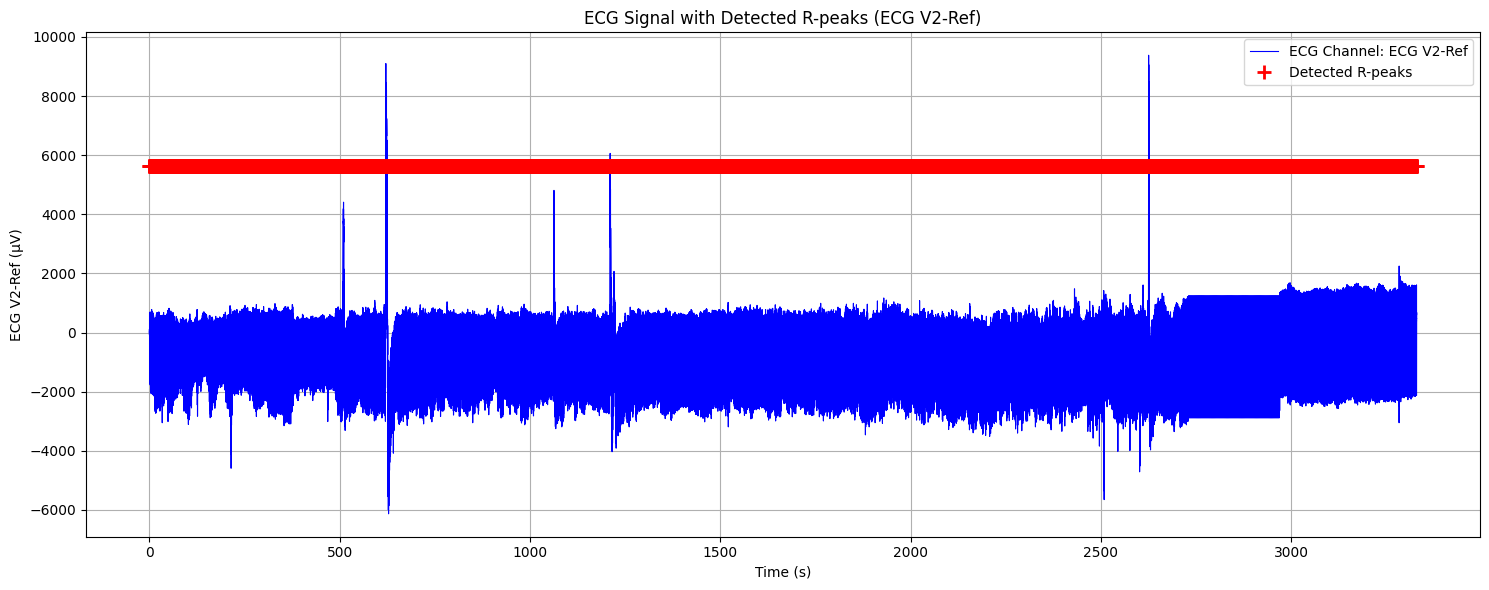

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Select the first ECG channel from the stored results
# Ensure these dictionaries are populated from the previous cell
if all_ecg_data and all_sfreq and all_indR and all_yR_markers:
    # Get the name of the first channel
    first_channel_name = list(all_ecg_data.keys())[0]

    ecg_data_to_plot = all_ecg_data[first_channel_name]
    sfreq_to_plot = all_sfreq[first_channel_name]
    indR_to_plot = all_indR[first_channel_name]
    yR_markers_to_plot = all_yR_markers[first_channel_name]

    # Plot the original ECG signal with detected R-peaks
    plt.figure(figsize=(15, 6))
    plt.plot(np.arange(len(ecg_data_to_plot)) / sfreq_to_plot, ecg_data_to_plot, 'b-', linewidth=0.8, label=f'ECG Channel: {first_channel_name}')
    plt.plot(np.array(indR_to_plot) / sfreq_to_plot, yR_markers_to_plot, '+r', markersize=10, markeredgewidth=2, label='Detected R-peaks')

    plt.xlabel('Time (s)')
    plt.ylabel(f'{first_channel_name} (µV)')
    plt.title(f'ECG Signal with Detected R-peaks ({first_channel_name})')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No ECG data available for plotting. Please run the R-peak detection cell first.")

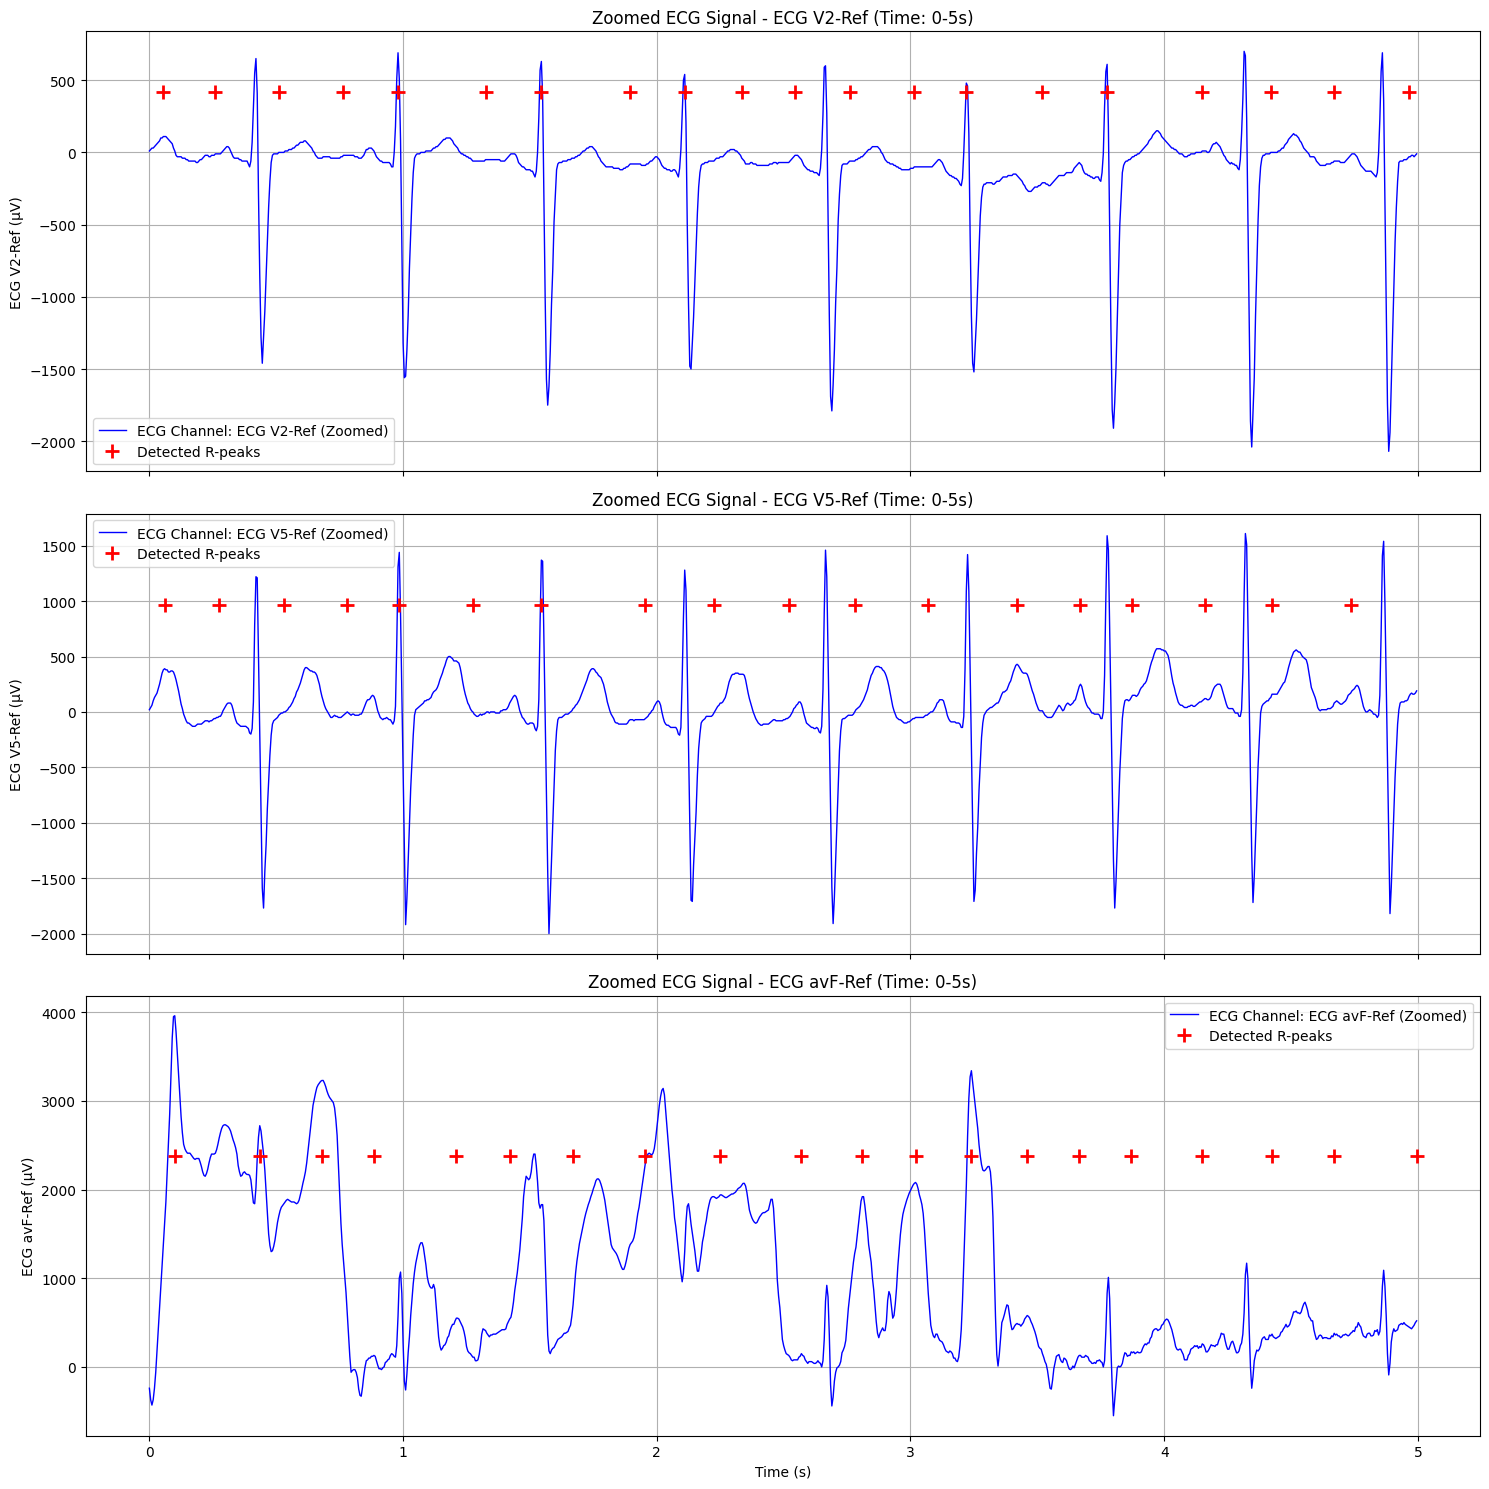

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the time window for the zoomed view (in seconds)
start_time = 0  # e.g., start at 0 seconds
end_time = 5    # e.g., end at 5 seconds

num_channels = len(all_ecg_data)
fig, axes = plt.subplots(num_channels, 1, figsize=(15, 5 * num_channels), sharex=True)

# Ensure axes is an array even for a single subplot
if num_channels == 1:
    axes = [axes]

for i, (channel_name, ecg_data) in enumerate(all_ecg_data.items()):
    sfreq = all_sfreq[channel_name]
    indR = all_indR[channel_name]
    yR_markers = all_yR_markers[channel_name]

    # Convert time window to sample indices
    start_sample = int(start_time * sfreq)
    end_sample = int(end_time * sfreq)

    # Ensure the window is within the bounds of ecg_data
    start_sample = max(0, start_sample)
    end_sample = min(len(ecg_data), end_sample)

    # Get the ECG data for the selected window
    zoomed_ecg_data = ecg_data[start_sample:end_sample]
    zoomed_time_axis = np.arange(start_sample, end_sample) / sfreq

    # Get the R-peak indices and markers that fall within the zoomed window
    zoomed_indR_indices = [idx for idx in indR if start_sample <= idx < end_sample]
    zoomed_yR_markers_for_plot = np.full(len(zoomed_indR_indices), np.max(zoomed_ecg_data) * 0.6 if len(zoomed_ecg_data) > 0 else 0)

    axes[i].plot(zoomed_time_axis, zoomed_ecg_data, 'b-', linewidth=1.0, label=f'ECG Channel: {channel_name} (Zoomed)')
    if len(zoomed_indR_indices) > 0:
        axes[i].plot(np.array(zoomed_indR_indices) / sfreq, zoomed_yR_markers_for_plot, '+r', markersize=10, markeredgewidth=2, label='Detected R-peaks')

    axes[i].set_ylabel(f'{channel_name} (µV)')
    axes[i].set_title(f'Zoomed ECG Signal - {channel_name} (Time: {start_time}-{end_time}s)')
    axes[i].grid(True)
    axes[i].legend()

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()